This example shows how one can work the SystemDS framework. More precisely, we will make use of the built-in DataManager, Multinomial Logistic Regression function, and the Confusion Matrix function. The dataset used in this tutorial is a preprocessed version of the “UCI Adult Data Set”. If one wants to skip the explanation then the full script is available at the end of this level.

We will train a Multinomial Logistic Regression model on the training dataset and subsequently use the test dataset to assess how well our model can predict if the income is above or below $50K/yr based on the features.

# Step 1: Load and prepare data
First, we get our training and testing data from the built-in DataManager. Since the multiLogReg function requires the labels (Y) to be > 0, we add 1 to all labels. This ensures that the smallest label is >= 1. Additionally we will only take a fraction of the training and test set into account to speed up the execution.

In [1]:
from systemds.context import SystemDSContext
from systemds.examples.tutorials.adult import DataManager
from systemds.operator.algorithm import multiLogReg
from systemds.operator.algorithm import multiLogRegPredict
from systemds.operator.algorithm import confusionMatrix

with SystemDSContext() as sds:
    d = DataManager()

    # limit the sample size
    train_count = 15000
    test_count = 5000

    # Get train and test datasets.
    X_frame, Y_frame, Xt_frame, Yt_frame = d.get_preprocessed_dataset(sds)

    # Transformation specification
    jspec_data = d.get_jspec(sds)
    jspec_labels = sds.scalar(f'"{ {"recode": ["income"]} }"')

    # Transform frames to matrices.
    X, M1 = X_frame.transform_encode(spec=jspec_data)
    Xt = Xt_frame.transform_apply(spec=jspec_data, meta=M1)  
    Y, M2 = Y_frame.transform_encode(spec=jspec_labels)
    Yt = Yt_frame.transform_apply(spec=jspec_labels, meta=M2)  
    
    # Subsample to make training faster
    X = X[0:train_count]
    Y = Y[0:train_count]
    Xt = Xt[0:test_count]
    Yt = Yt[0:test_count]

26/05/06 15:19:28 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Here the DataManager contains the code for downloading and setting up either Pandas DataFrames or internal SystemDS Frames, for the best performance and no data transfer from pandas to SystemDS it is recommended to read directly from disk into SystemDS.

# Step 2: Training
Now that we prepared the data, we can use the multiLogReg function. First, we will train the model on our training data. Afterward, we can make predictions on the test data and assess the performance of the model.

In [2]:
betas = multiLogReg(X, Y, verbose=False)

Note that nothing has been calculated yet. In SystemDS the calculation is executed once `compute()` is called. E.g. `betas_res = betas.compute()`.

We can now use the trained model to make predictions on the test data.

In [3]:
[_, y_pred, acc] = multiLogRegPredict(Xt, betas, Y=Yt)

The multiLogRegPredict function has three return values:

`m`, a matrix with the mean probability of correctly classifying each label. We do not use it further in this example.

`y_pred`, is the predictions made using the model

`acc`, is the accuracy achieved by the model.

# Step 3: Confusion Matrix
A confusion matrix is a useful tool to analyze the performance of the model and to obtain a better understanding which classes the model has difficulties separating. The confusionMatrix function takes the predicted labels and the true labels. It then returns the confusion matrix for the predictions and the confusion matrix averages of each true class.

In [ ]:
confusion_matrix_abs, _ = confusionMatrix(y_pred, Yt).compute()

# Full Script

In [1]:
from systemds.context import SystemDSContext
from systemds.examples.tutorials.adult import DataManager
from systemds.operator.algorithm import multiLogReg
from systemds.operator.algorithm import multiLogRegPredict
from systemds.operator.algorithm import confusionMatrix
from systemds.operator.algorithm import getAccuracy

import logging
logger = logging.getLogger('python_e2e_l1_example')
logger.setLevel(logging.INFO)

with SystemDSContext() as sds:
    d = DataManager()

    # limit the sample size
    train_count = 15000
    test_count = 5000

    # Get train and test datasets.
    X_frame, Y_frame, Xt_frame, Yt_frame = d.get_preprocessed_dataset(sds)

    # Transformation specification
    jspec_data = d.get_jspec(sds)
    jspec_labels = sds.scalar(f'"{ {"recode": ["income"]} }"')

    # Transform frames to matrices.
    X, M1 = X_frame.transform_encode(spec=jspec_data)
    Xt = Xt_frame.transform_apply(spec=jspec_data, meta=M1)  
    Y, M2 = Y_frame.transform_encode(spec=jspec_labels)
    Yt = Yt_frame.transform_apply(spec=jspec_labels, meta=M2)  
    
    # Subsample to make training faster
    X = X[0:train_count]
    Y = Y[0:train_count]
    Xt = Xt[0:test_count]
    Yt = Yt[0:test_count]

    # Train model    
    betas = multiLogReg(X, Y, verbose=False)

    # Apply model
    [_, y_pred, acc] = multiLogRegPredict(Xt, betas, Y=Yt)

    # Confusion Matrix
    confusion_matrix_abs, _ = confusionMatrix(y_pred, Yt).compute()
    
    # accuracy = getAccuracy(Yt, y_pred).compute()


    logger.info("Confusion Matrix")
    logger.info(confusion_matrix_abs)

26/05/06 16:39:07 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
INFO:python_e2e_l1_example:Confusion Matrix
INFO:python_e2e_l1_example:[[3580.  488.]
 [ 248.  684.]]


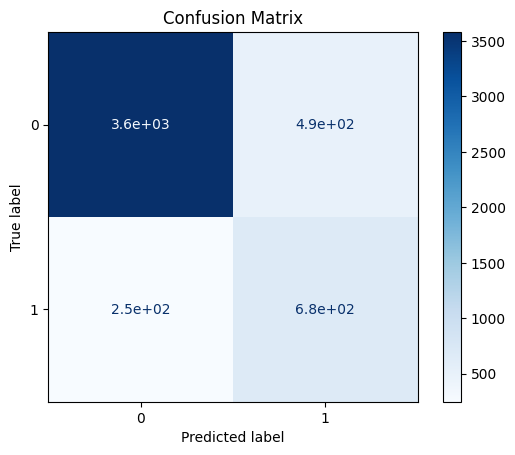

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_abs)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

The Confusion Matrix created has four different quadrants:

- True Negative (Top-Left Quadrant)
- False Positive (Top-Right Quadrant)
- False Negative (Bottom-Left Quadrant)
- True Positive (Bottom-Right Quadrant)

True means that the values were accurately predicted, False means that there was an error or wrong prediction.

In [3]:
confusion_matrix_abs

array([[3580.,  488.],
       [ 248.,  684.]])

# Accuracy

Accuracy measures how often the model is correct.

(True Positive + True Negative) / Total Predictions



In [4]:
TN, FP, FN, TP = confusion_matrix_abs[0,0], confusion_matrix_abs[0,1], confusion_matrix_abs[1,0], confusion_matrix_abs[1,1]

In [5]:
# from systemds.operator.algorithm import getAccuracy
# accuracy = getAccuracy(Yt, y_pred).compute()


accuracy = (TP + TN) / test_count
accuracy

np.float64(0.8528)

# Precision
Of the positives predicted, what percentage is truly positive?

True Positive / (True Positive + False Positive)

In [6]:
precision = TP / (TP + FP)
precision

np.float64(0.5836177474402731)

# Sensitivity (Recall)
Of all the positive cases, what percentage are predicted positive?

Sensitivity (sometimes called Recall) measures how good the model is at predicting positives.

This means it looks at true positives and false negatives (which are positives that have been incorrectly predicted as negative).

True Positive / (True Positive + False Negative)


In [7]:
sensitivity = TP /(TP + FN)
sensitivity

np.float64(0.7339055793991416)

# Specificity
How well the model is at prediciting negative results?

Specificity is similar to sensitivity, but looks at it from the persepctive of negative results.

True Negative / (True Negative + False Positive)

In [8]:
specificity = TN / (TN + FP)
specificity

np.float64(0.880039331366765)

# F-score
F-score is the "harmonic mean" of precision and sensitivity.

It considers both false positive and false negative cases and is good for imbalanced datasets.

2 * ((Precision * Sensitivity) / (Precision + Sensitivity))

In [9]:
f_score = 2 * ((precision * sensitivity) / (precision + sensitivity))
f_score

np.float64(0.6501901140684411)